# R01 — bounded Mixed Signals development intake

This notebook displays the executed mini_7 intake tables and geometry. It does not load label bodies or perform scoring. The immutable run manifest and full inventories are linked below.

In [1]:
from pathlib import Path
import json
from IPython.display import display, Markdown, Image
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RUN = ROOT / 'artifacts' / '20261008T192922Z-R01'
assert RUN.is_dir(), RUN
schema = json.loads((RUN / 'T_R01_schema.json').read_text())
timing = json.loads((RUN / 'T_R01_timing.json').read_text())
feasibility = json.loads((RUN / 'T_R01_component_feasibility.json').read_text())
geometry = json.loads((RUN / 'geometry_diagnostics.json').read_text())
manifest = json.loads((RUN / 'manifest.json').read_text())
print('Run:', RUN.name, '| archive SHA-256:', manifest['input_sha256'][schema['archive']])
print('Selected:', timing['selected_count'], 'clouds,', schema['selected_bytes'], 'bytes; window:', timing['window_start_ns'], 'to', timing['window_end_ns_exclusive'])

Run: 20261008T192922Z-R01 | archive SHA-256: 46e9dbe9f6e952be9186a6271abbcaaf11c965a5589d785fc278afd3eb235663
Selected: 250 clouds, 1312497280 bytes; window: 1712121167080167605 to 1712121172080167605


## T_R01_schema — actual PCD headers and CSV columns

In [2]:
print('Safe members:', schema['member_count'], '| label filenames (bodies unopened):', len(schema['label_filenames_only']))
for stream, stats in schema['selected_stats'].items():
    print(stream, 'principal=', timing['stream_to_principal'][stream], 'clouds=', stats['cloud_count'], 'points=', stats['point_count'], 'fields=', stats['observed_fields'], 'encoding=', stats['encodings'], 'nonfinite XYZ=', stats['nonfinite_xyz'], 'raw intensity range=', (stats['intensity_min'], stats['intensity_max']))
for path, header in schema['headers_first_middle_last'].items():
    print('\n', path, '\n', header['raw'], sep='')

Safe members: 1788 | label filenames (bodies unopened): 290
003 principal= 003 clouds= 50 points= 13107200 fields= ['x', 'y', 'z', 'intensity'] encoding= {'ascii': 50} nonfinite XYZ= 0 raw intensity range= (0.0, 0.0)
004 principal= 004 clouds= 50 points= 13107200 fields= ['x', 'y', 'z', 'intensity'] encoding= {'ascii': 50} nonfinite XYZ= 0 raw intensity range= (0.0, 0.0)
dome principal= RSU clouds= 50 points= 6553600 fields= ['x', 'y', 'z', 'intensity'] encoding= {'ascii': 50} nonfinite XYZ= 0 raw intensity range= (1.0, 2878.0)
laser principal= laser clouds= 50 points= 6553600 fields= ['x', 'y', 'z', 'intensity'] encoding= {'ascii': 50} nonfinite XYZ= 0 raw intensity range= (2.0, 5733.0)
top principal= RSU clouds= 50 points= 3276800 fields= ['x', 'y', 'z', 'intensity'] encoding= {'ascii': 50} nonfinite XYZ= 0 raw intensity range= (1.0, 5702.0)

PointClouds/mini_7/003_0_1712121167.80167605.pcd
# .PCD v0.7 - Point Cloud Data file format
VERSION 0.7
FIELDS x y z intensity
SIZE 4 4 4 4
TYP

In [3]:
for stream, info in schema['odometry'].items():
    print('\n', stream, '| rows=', info['row_count'], '| exact columns (', len(info['columns']), '):', sep='')
    print(', '.join(info['columns']))
    print('stamp gap ns:', info['gap_ns'], '| quaternion norm:', info['quaternion_norm'], '| missing required:', info['required_missing'])
    for name in ['field.pose.pose.position.x', 'field.pose.pose.orientation.w', 'field.twist.twist.linear.x', 'field.twist.twist.angular.z']:
        print(name, info['column_diagnostics'].get(name))
    print('sample:', info['sample_rows'][0] if info['sample_rows'] else None)


003| rows=300| exact columns (90):
%time, field.header.seq, field.header.stamp, field.header.frame_id, field.child_frame_id, field.pose.pose.position.x, field.pose.pose.position.y, field.pose.pose.position.z, field.pose.pose.orientation.x, field.pose.pose.orientation.y, field.pose.pose.orientation.z, field.pose.pose.orientation.w, field.pose.covariance0, field.pose.covariance1, field.pose.covariance2, field.pose.covariance3, field.pose.covariance4, field.pose.covariance5, field.pose.covariance6, field.pose.covariance7, field.pose.covariance8, field.pose.covariance9, field.pose.covariance10, field.pose.covariance11, field.pose.covariance12, field.pose.covariance13, field.pose.covariance14, field.pose.covariance15, field.pose.covariance16, field.pose.covariance17, field.pose.covariance18, field.pose.covariance19, field.pose.covariance20, field.pose.covariance21, field.pose.covariance22, field.pose.covariance23, field.pose.covariance24, field.pose.covariance25, field.pose.covariance26, f

## T_R01_timing — source stamps, synchronization IDs and causal poses

In [4]:
for stream in timing['stream_to_principal']:
    rows = [r for r in timing['rows'] if r['stream'] == stream]
    print(stream, 'principal=', timing['stream_to_principal'][stream], 'first=', [(r['sync_id'], r['source_text'], r['source_ns'], r['pose_age_ns']) for r in rows[:3]], 'last=', (rows[-1]['sync_id'], rows[-1]['source_text']) if rows else None)
    print('  nearest reference uses future:', sum(r['reference_uses_future'] for r in rows), 'differs from latest past:', sum(r['reference_differs'] for r in rows))
    print('  full stream ID diagnostics:', schema['streams'][stream])
print('Receipt model:', timing['receipt_assumption'])

003 principal= 003 first= [(0, '1712121167.80167605', 1712121167080167605, 0), (1, '1712121167.180137050', 1712121167180137050, 0), (2, '1712121167.280192786', 1712121167280192786, 0)] last= (49, '1712121171.980195717')
  nearest reference uses future: 0 differs from latest past: 0
  full stream ID diagnostics: {'count': 299, 'duplicate_ids': {}, 'duplicate_source_ns': {}, 'id_max': 298, 'id_min': 0, 'missing_ids': [], 'positive_id_order_gap_ns': {'max': 100231666, 'median': 100002987, 'min': 99781409}, 'short_subsecond_count': 30, 'source_reversals_in_id_order': 0}
004 principal= 004 first= [(0, '1712121167.98507153', 1712121167098507153, 0), (1, '1712121167.198532918', 1712121167198532918, 0), (2, '1712121167.298563758', 1712121167298563758, 0)] last= (49, '1712121171.998747820')
  nearest reference uses future: 0 differs from latest past: 0
  full stream ID diagnostics: {'count': 299, 'duplicate_ids': {}, 'duplicate_source_ns': {}, 'id_max': 298, 'id_min': 0, 'missing_ids': [], 'pos

## T_R01_component_feasibility and F_R01_geometry

| Component | Status | Basis | Limit |
|---|---|---|---|
| density | feasible | observed ASCII XYZ and point counts; sensor-specific raw counts | no reference fit or decision threshold in R01 |
| temporal_geometry | conditional | latest-past odometry and source stamps available | scan timing, deskewing and clock-error bounds unverified; static consistency requires review |
| cross_agent_geometry | conditional | four principals in selected interval; map/top transforms and raw RSU conventions | geometric overlap is not visibility; physical vehicle extrinsics and calibration not independently verified |
| kinematics | conditional | twist columns are present and variable in CSV | measurement provenance and frame semantics not established; no cloud integrity inference |
| intensity | excluded | raw intensity preserved | cross-device radiometric comparability not established |

Pinned transform constants and paired offsets: [-41.551, -51.878, -1.077] [-41.507, -51.864, -1.34] [0.044000000000004036, 0.014000000000002899, -0.2630000000000001] {'cloud': -3.25, 'net_raw_to_map': 0, 'pose_right_composed': 3.25}
Top/dome sampled static occupancy overlap: [{'dome_voxels': 1145, 'interpretation': 'sampled occupancy overlap is viewpoint dependent; not a calibration fit', 'intersection': 299, 'jaccard': 0.14097123998114097, 'resolution_m': 0.5, 'sample_index': 0, 'top_voxels': 1275}, {'dome_voxels': 1178, 'interpretation': 'sampled occupancy overlap is viewpoint dependent; not a calibration fit', 'intersection': 347, 'jaccard': 0.15968706856879888, 'resolution_m': 0.5, 'sample_index': 25, 'top_voxels': 1342}, {'dome_voxels': 1186, 'interpretation': 'sampled occupancy overlap is viewpoint dependent; not a calibration fit', 'intersection': 354, 'jaccard': 0.1644217371110079, 'resolution_m': 0.5, 'sample_index': 49, 'top_voxels': 1321}]


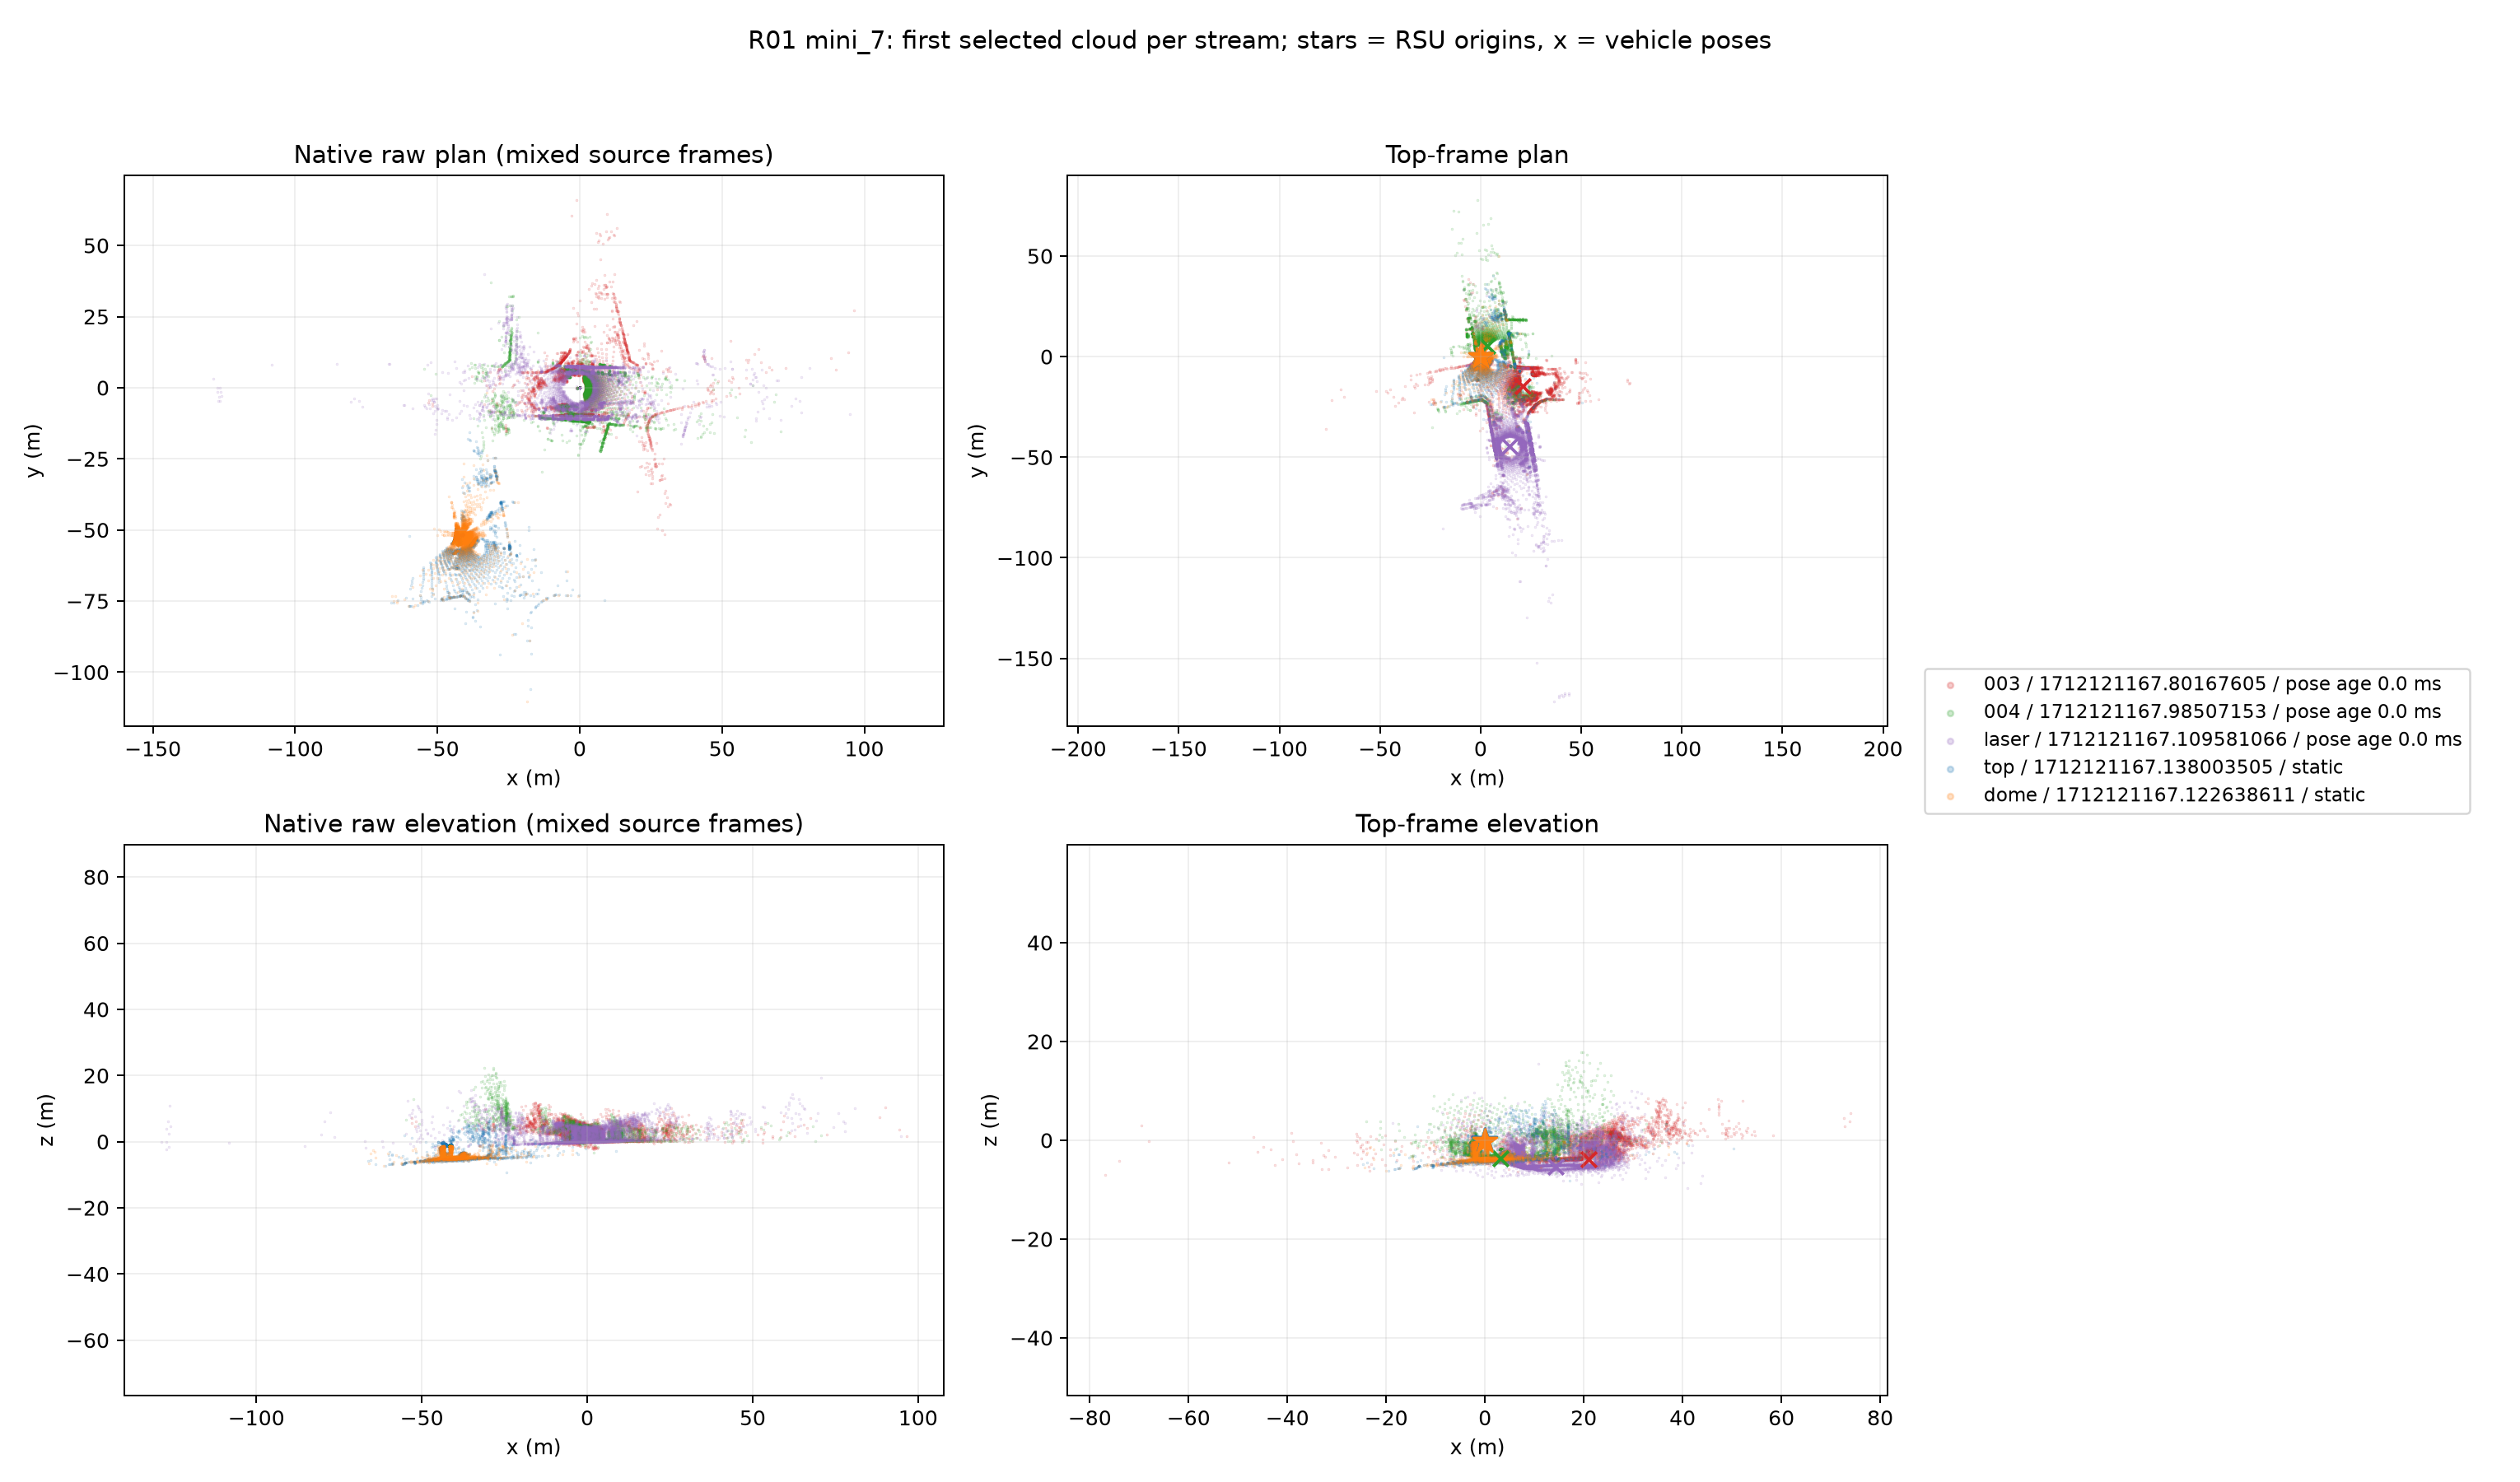

In [5]:
display(Markdown('| Component | Status | Basis | Limit |\n|---|---|---|---|\n' + '\n'.join('| {component} | {status} | {basis} | {limits} |'.format(**row) for row in feasibility)))
print('Pinned transform constants and paired offsets:', geometry['top_map_translation_m'], geometry['dome_map_translation_m'], geometry['dome_origin_in_top_m'], geometry['vehicle_paired_z_m'])
print('Top/dome sampled static occupancy overlap:', geometry['static_overlap'])
display(Image(filename=str(RUN / 'F_R01_geometry.png')))

The native panels mix coordinate frames intentionally. The top-frame panels apply the pinned map/pose conventions; the stars show the two RSU sensor origins. This visual is diagnostic evidence of gross placement only. Shared stationary surfaces, physical extrinsics, scan timing and clock-error bounds remain unverified; overlapping geometry is not a visibility guarantee. Full data, hashes and execution log are in the run directory.